# 05 — Biomechanics Baseline & Efficiency Assessment

**Goal:** establish where each athlete currently sits in their running biomechanics,
compare against a population reference for solid recreational runners, and determine
which biomechanical deviations actually cost running efficiency — versus which are
just personal style.

**Key principle:** the 180 spm cadence norm is irrelevant in isolation. An athlete
running 160 spm with vertical ratio 6.5% and GCT 210ms is more efficient than one
hitting 180 spm with VR 9.5% and GCT 290ms. Vertical ratio is the primary efficiency
proxy — it directly measures what fraction of energy goes vertical (wasted) vs
horizontal (useful).

**Scope:** road running sessions only. Terrain stratification deferred until more data
is available.

**Outputs:**
- `data/biomechanics_vs_population.png` — athlete positions vs population reference bands
- `data/efficiency_by_speed.png` — VR and HR-speed efficiency per athlete
- `data/baseline_regressions.png` — personal speed-conditional baseline per variable
- `data/residual_distributions.png` — residual distributions, normality, personal σ
- `data/efficiency_correlation.png` — which biomechanics deviations correlate with worse VR
- `data/baseline_stability.png` — how many sessions before the baseline stabilises

In [52]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats
from scipy.stats import linregress, shapiro

warnings.filterwarnings('ignore')

# ── Athletes ─────────────────────────────────────────────────────────────────
DATA_ROOT = '../data'
ATHLETES = {
    'Vlad':    {'data_dir': DATA_ROOT,               'age': 22},
    'Ciulavu': {'data_dir': f'{DATA_ROOT}/Ciulavu',  'age': 22},
    'Mircea':  {'data_dir': f'{DATA_ROOT}/Mircea',   'age': 22},
}
ATHLETE_COLORS = {'Vlad': '#4FC3F7', 'Ciulavu': '#81C784', 'Mircea': '#FF8A65'}
RUNNING_SPORTS = {'running', 'trail_running'}

# ── Cleaning constants ────────────────────────────────────────────────────────
# 180s strip (not 120s): cardiac lag is ~120s but neuromuscular patterns
# — cadence, GCT, VO — take longer to settle into steady-state form.
WARMUP_STRIP_S      = 180

# 2.0 m/s floor (not 1.5): below this the gait is transitioning between walk
# and jog. Biomechanics at sub-running speeds would distort the baseline.
SPEED_FLOOR_MS      = 2.0

# Dynamic ceiling: each athlete's 95th percentile of road running speed.
# Sprinting mechanics are a different regime and would skew the baseline.
SPEED_PCT_CEILING   = 95

# GPS gap detection: a gap > 60s between consecutive records means GPS dropout
# or auto-pause. Speed and gradient in that window are dead-reckoned (estimated
# by accelerometer), not measured. Since the entire baseline model is
# speed-conditional, records without reliable speed context are useless.
# The ±30s buffer around each gap removes records where gradient_pct is
# computed from the bad distance derivative.
GPS_GAP_THRESHOLD_S = 60
GPS_GAP_BUFFER_S    = 30

MIN_DURATION_S      = 600    # 10 min of clean records after warmup strip
MIN_DISTANCE_M      = 1500   # 1.5 km after warmup strip
MIN_COVERAGE_PCT    = 0.50   # exclude variable for a session if >50% null

# ── Per-second biomechanics sanity bounds ─────────────────────────────────────
# These catch sensor glitches and GPS artifacts before they pollute aggregates.
# vertical_oscillation is in cm (parsed as mm/10 in notebook 00).
SANITY = {
    'cadence':              (100, 240),   # spm
    'stance_time':          (100, 500),   # ms
    'vertical_oscillation': (2.0, 20.0), # cm
    'vertical_ratio':       (3.0, 20.0), # %
    'step_length':          (200, 2000), # mm
    'speed_ms':             (0.0, 7.0),  # m/s — above 7 is GPS spike artifact
}

BIOMECH_VARS = ['cadence', 'vertical_oscillation', 'vertical_ratio', 'stance_time']
VAR_LABELS = {
    'cadence':              ('Cadence',              'spm'),
    'vertical_oscillation': ('Vertical Oscillation', 'cm'),
    'vertical_ratio':       ('Vertical Ratio',       '%'),
    'stance_time':          ('Ground Contact Time',  'ms'),
}

print('Config loaded.')

Config loaded.


## 1. Load data

In [53]:
datasets = {}
for name, cfg in ATHLETES.items():
    s = pd.read_parquet(os.path.join(cfg['data_dir'], 'sessions.parquet'))
    r = pd.read_parquet(os.path.join(cfg['data_dir'], 'records.parquet'))
    s['athlete'] = name
    r['athlete'] = name
    datasets[name] = {'sessions': s, 'records': r}
    runs = s[s['sport'].isin(RUNNING_SPORTS)]
    print(f'[{name}]  total sessions: {len(s)}  running: {len(runs)}  total records: {len(r):,}')

[Vlad]  total sessions: 38  running: 5  total records: 83,459
[Ciulavu]  total sessions: 248  running: 56  total records: 488,924
[Mircea]  total sessions: 164  running: 98  total records: 320,730


## 2. Signal coverage audit

Before any filtering, check which biomechanics signals are actually present per athlete.
GCT, VO, VR, and step length require running dynamics capability (wrist sensor or pod).
Some sessions will have HR + cadence only — we need to know the scale of this problem
before committing to which variables go into the model.

In [54]:
print('Signal coverage across all running records\n')
for name, d in datasets.items():
    runs = d['sessions'][d['sessions']['sport'].isin(RUNNING_SPORTS)]
    run_ids = set(runs['session_id'])
    rr = d['records'][d['records']['session_id'].isin(run_ids)]
    total = len(rr)
    print(f'[{name}]  {len(runs)} sessions  |  {total:,} records')
    check_vars = BIOMECH_VARS + ['heart_rate', 'speed_ms', 'gradient_pct']
    for var in check_vars:
        if var not in rr.columns:
            pct = 0.0
        else:
            pct = rr[var].notna().mean() * 100
        filled = int(pct / 5)
        bar = '█' * filled + '░' * (20 - filled)
        flag = '  ← sparse' if pct < 50 and var in BIOMECH_VARS else ''
        print(f'  {var:<25s} {bar}  {pct:5.1f}%{flag}')
    print()

Signal coverage across all running records

[Vlad]  5 sessions  |  6,153 records
  cadence                   ████████████████████  100.0%
  vertical_oscillation      ███████████████████░   97.5%
  vertical_ratio            ███████████████████░   96.6%
  stance_time               ██████████████████░░   90.5%
  heart_rate                ████████████████████  100.0%
  speed_ms                  ███████████████████░   99.5%
  gradient_pct              ███████████████████░   96.9%

[Ciulavu]  56 sessions  |  153,268 records
  cadence                   ████████████████████  100.0%
  vertical_oscillation      █████████████████░░░   86.2%
  vertical_ratio            ██████████████░░░░░░   73.1%
  stance_time               █████████████░░░░░░░   67.5%
  heart_rate                ████████████████████  100.0%
  speed_ms                  ██████████████████░░   91.8%
  gradient_pct              █████████████████░░░   85.2%

[Mircea]  98 sessions  |  212,720 records
  cadence                   ██████

## 3. Road / trail classification

Terrain is classified from the **`sport` field in the FIT file**. The athlete
explicitly selects Run vs Trail Run on their Garmin before starting — that label
is the ground truth.

Gradient is not used for classification. In a hilly city like Cluj-Napoca, road
runs naturally carry significant elevation change. A gradient threshold would
incorrectly exclude valid road sessions. Additionally, per-second `gradient_pct`
is a noisy derivative (GPS altitude ±5–10m accuracy divided by 1–2m distance)
that produces large spikes on flat ground — it is useful for within-session
context but not as a session-level classifier.

- `sport == 'running'` → road  
- `sport == 'trail_running'` → trail  

Both terrain types will eventually have separate baselines. At current session
counts only road has enough data.

In [55]:
ROAD_SPORT  = 'running'
TRAIL_SPORT = 'trail_running'

print('Terrain classification: sport field from FIT file\n')
for name, d in datasets.items():
    runs = d['sessions'][d['sessions']['sport'].isin(RUNNING_SPORTS)].copy()
    runs['terrain'] = runs['sport'].map(
        {ROAD_SPORT: 'road', TRAIL_SPORT: 'trail'}
    ).fillna('unknown')
    d['runs_classified'] = runs
    counts = runs['terrain'].value_counts()
    print(f'[{name}]  road: {counts.get("road", 0)}  '
          f'trail: {counts.get("trail", 0)}  '
          f'unknown: {counts.get("unknown", 0)}')
    print(f'  → using {counts.get("road", 0)} road sessions for baseline')

Terrain classification: sport field from FIT file

[Vlad]  road: 5  trail: 0  unknown: 0
  → using 5 road sessions for baseline
[Ciulavu]  road: 56  trail: 0  unknown: 0
  → using 56 road sessions for baseline
[Mircea]  road: 98  trail: 0  unknown: 0
  → using 98 road sessions for baseline


## 4. Data cleaning pipeline + Grade Adjusted Pace

Applied in this order per session:

1. **Warmup strip (180s)** — neuromuscular patterns take longer to settle than HR
2. **Speed floor 2.0 m/s** — excludes walk/jog transitions
3. **Speed ceiling (95th pct per athlete)** — excludes sprinting, a different biomechanical regime
4. **GPS gap masking** — gaps > 60s = dropout; mask ±30s around each gap
5. **Per-second sanity bounds** — hard-clip artifact values to NaN
6. **Grade Adjusted Pace (GAP)** — converts actual speed to flat-equivalent speed using
   the Minetti et al. (2002) metabolic cost formula. This is the key step for hilly cities:
   a 3 m/s uphill run at 10% grade is mechanically equivalent to ~5 m/s on flat.
   Gradient is smoothed over a 30s rolling window before applying the formula —
   this removes GPS altitude noise (spikes from ±5m altitude error) while preserving
   real sustained gradients from actual hills.
7. **Minimum session size** — 10 min or 1.5km of clean records
8. **Per-variable coverage** — exclude variable for a session if >50% null

In [56]:
def minetti_gap_factor(grade_decimal):
    """
    Metabolic cost ratio vs flat, from Minetti et al. (2002).
    grade_decimal: signed grade (-0.10 = 10% downhill, +0.10 = 10% uphill).
    Returns factor by which to multiply actual speed to get flat-equivalent speed.
    Validated range: ±45% grade. Outside this the polynomial extrapolates badly.

    C(g) = 155.4g⁵ − 30.4g⁴ − 43.3g³ + 46.3g² + 19.5g + 3.6  (J/kg/m)
    flat reference C(0) = 3.6 J/kg/m
    """
    g = np.clip(grade_decimal, -0.45, 0.45)
    cost = (155.4*g**5 - 30.4*g**4 - 43.3*g**3 + 46.3*g**2 + 19.5*g + 3.6)
    return cost / 3.6  # 3.6 = C(0), flat reference


def clean_records(session_id, records_df, speed_ceiling_ms):
    """
    Apply the full cleaning pipeline to per-second records for one session.
    Returns cleaned DataFrame with gap_speed_ms column, or None if session
    fails minimum size check.
    """
    df = records_df[records_df['session_id'] == session_id].copy()
    df = df.sort_values('timestamp').reset_index(drop=True)
    if df.empty:
        return None

    # 1. Warmup strip
    t0 = df['timestamp'].min()
    df = df[df['timestamp'] >= t0 + pd.Timedelta(seconds=WARMUP_STRIP_S)].reset_index(drop=True)
    if df.empty:
        return None

    # 2 & 3. Speed bounds (floor + dynamic ceiling)
    df = df[
        (df['speed_ms'] >= SPEED_FLOOR_MS) &
        (df['speed_ms'] <= speed_ceiling_ms)
    ].reset_index(drop=True)
    if df.empty:
        return None

    # 4. GPS gap masking
    if len(df) > 1:
        dt_seconds = df['timestamp'].diff().dt.total_seconds()
        gap_locs   = df.index[dt_seconds > GPS_GAP_THRESHOLD_S]
        mask       = pd.Series(False, index=df.index)
        for idx in gap_locs:
            gap_ts  = df.loc[idx, 'timestamp']
            prev_ts = df.loc[idx - 1, 'timestamp'] if idx > 0 else gap_ts
            mask |= (
                (df['timestamp'] >= prev_ts - pd.Timedelta(seconds=GPS_GAP_BUFFER_S)) &
                (df['timestamp'] <= gap_ts  + pd.Timedelta(seconds=GPS_GAP_BUFFER_S))
            )
        df = df[~mask].reset_index(drop=True)
    if df.empty:
        return None

    # 5. Per-second sanity bounds — null out artifacts, keep the record
    for var, (lo, hi) in SANITY.items():
        if var in df.columns:
            df.loc[~df[var].between(lo, hi, inclusive='both'), var] = np.nan

    # 6. Grade Adjusted Pace (GAP)
    # Smooth gradient over 30s rolling window to remove GPS altitude noise.
    # Real hills in Cluj are sustained (tens of seconds); GPS noise is per-second.
    # A 30s window averages noise to ~0 while preserving real gradients.
    if 'gradient_pct' in df.columns:
        grade_smooth = (
            df['gradient_pct']
            .rolling(window=30, center=True, min_periods=10)
            .mean()
            .fillna(0)
            / 100  # pct → decimal
        )
        gap_factor        = minetti_gap_factor(grade_smooth)
        df['gap_speed_ms'] = (df['speed_ms'] * gap_factor).clip(lower=0)
    else:
        df['gap_speed_ms'] = df['speed_ms']

    # 7. Minimum session size after all cleaning
    if len(df) < 2:
        return None
    duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
    dist_col = df['distance'].dropna()
    distance = (dist_col.max() - dist_col.min()) if len(dist_col) > 1 else 0
    if duration < MIN_DURATION_S or (distance > 0 and distance < MIN_DISTANCE_M):
        return None

    return df


def get_speed_ceiling(name):
    """Dynamic ceiling: 95th percentile of actual road running speed (not GAP)."""
    d     = datasets[name]
    runs  = d['runs_classified']
    r_ids = set(runs[runs['terrain'] == 'road']['session_id'])
    spd   = d['records'][d['records']['session_id'].isin(r_ids)]['speed_ms'].dropna()
    return spd.quantile(SPEED_PCT_CEILING / 100)


# Quick sanity check on the Minetti formula
test_grades = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15, 0.20]
print('Minetti GAP factors at representative grades:\n')
print(f'  {"Grade":>8}  {"GAP factor":>12}  Interpretation')
print('  ' + '-' * 50)
for g in test_grades:
    f = minetti_gap_factor(g)
    interp = f'flat 3m/s → GAP {3*f:.2f} m/s ({1000/3/f/60:.2f} min/km equiv.)'
    print(f'  {g*100:>7.0f}%  {f:>12.3f}  {interp}')
print()
print('Cleaning pipeline + GAP defined.')

Minetti GAP factors at representative grades:

     Grade    GAP factor  Interpretation
  --------------------------------------------------
      -15%         0.510  flat 3m/s → GAP 1.53 m/s (10.90 min/km equiv.)
      -10%         0.598  flat 3m/s → GAP 1.79 m/s (9.29 min/km equiv.)
       -5%         0.763  flat 3m/s → GAP 2.29 m/s (7.28 min/km equiv.)
        0%         1.000  flat 3m/s → GAP 3.00 m/s (5.56 min/km equiv.)
        5%         1.301  flat 3m/s → GAP 3.90 m/s (4.27 min/km equiv.)
       10%         1.658  flat 3m/s → GAP 4.97 m/s (3.35 min/km equiv.)
       15%         2.060  flat 3m/s → GAP 6.18 m/s (2.70 min/km equiv.)
       20%         2.502  flat 3m/s → GAP 7.51 m/s (2.22 min/km equiv.)

Cleaning pipeline + GAP defined.


## 5. Session-level aggregation

After cleaning, each session is reduced to a single row: mean speed, mean HR,
elevation gain per km, and mean of each biomechanics variable.

**Why elevation_per_km matters:** a road run with 40 m/km of climbing in Cluj
produces shorter strides, different GCT, and higher VO than a flat run at the
same speed. If the baseline model ignores this, hilly sessions look like form
deviations when they are just elevation-driven mechanics. Including elevation as
a second predictor separates the two effects.

`elevation_per_km = total_ascent / (distance_m / 1000)` — from the session
table's barometric altimeter reading, not from the noisy per-second GPS derivative.

In [57]:
def aggregate_session(df, session_info):
    """Produce one summary row from a cleaned per-second DataFrame."""
    row = {
        'session_id':       session_info['session_id'],
        'date':             session_info['date'],
        'athlete':          session_info.get('athlete', ''),
        'terrain':          session_info.get('terrain', 'road'),
        'n_clean_records':  len(df),
        'mean_speed':       df['speed_ms'].mean(),
        'mean_gap_speed':   df['gap_speed_ms'].mean() if 'gap_speed_ms' in df.columns else df['speed_ms'].mean(),
        'std_speed':        df['speed_ms'].std(),
        'mean_hr':          df['heart_rate'].mean() if 'heart_rate' in df.columns else np.nan,
        'elevation_per_km': (session_info.get('total_ascent', 0) /
                             max(session_info.get('distance_m', 1) / 1000, 0.1)),
    }
    row['gap_uplift']  = row['mean_gap_speed'] - row['mean_speed']  # how much elevation added
    row['cv_speed']    = row['std_speed'] / row['mean_speed'] if row['mean_speed'] > 0 else np.nan

    for var in BIOMECH_VARS:
        if var not in df.columns:
            row[f'mean_{var}'] = np.nan
            row[f'cv_{var}']   = np.nan
            continue
        col = df[var].dropna()
        coverage = len(col) / len(df)
        if coverage >= MIN_COVERAGE_PCT and len(col) > 0:
            row[f'mean_{var}'] = col.mean()
            row[f'cv_{var}']   = col.std() / col.mean() if col.mean() > 0 else np.nan
        else:
            row[f'mean_{var}'] = np.nan
            row[f'cv_{var}']   = np.nan
    return row


print('Building clean session aggregates...\n')
all_sessions   = []
rejection_log  = {name: {'too_short': 0, 'accepted': 0} for name in ATHLETES}

for name, d in datasets.items():
    speed_ceil = get_speed_ceiling(name)
    road_runs  = d['runs_classified'][d['runs_classified']['terrain'] == 'road']
    print(f'[{name}]  speed ceiling: {speed_ceil:.2f} m/s  |  road sessions: {len(road_runs)}')

    for _, sess in road_runs.iterrows():
        cleaned = clean_records(sess['session_id'], d['records'], speed_ceil)
        if cleaned is None:
            rejection_log[name]['too_short'] += 1
            continue
        row = aggregate_session(cleaned, sess.to_dict())
        all_sessions.append(row)
        rejection_log[name]['accepted'] += 1

    acc = rejection_log[name]['accepted']
    rej = rejection_log[name]['too_short']
    print(f'  accepted: {acc}  rejected: {rej}\n')

df_sessions = pd.DataFrame(all_sessions)
print(f'Total clean road sessions: {len(df_sessions)}\n')

# GAP uplift summary — how much elevation is inflating the effective effort
print('GAP uplift per athlete (mean_gap_speed − mean_speed):')
print(f'  {"Athlete":<10}  {"Sessions":>8}  {"Elev m/km":>10}  {"Actual spd":>11}  {"GAP spd":>9}  {"Uplift":>8}')
print('  ' + '-' * 62)
for name in ATHLETES:
    sub = df_sessions[df_sessions['athlete'] == name]
    if sub.empty:
        continue
    print(f'  {name:<10}  {len(sub):>8}  '
          f'{sub["elevation_per_km"].mean():>9.1f}  '
          f'{sub["mean_speed"].mean():>10.2f} m/s  '
          f'{sub["mean_gap_speed"].mean():>8.2f} m/s  '
          f'+{sub["gap_uplift"].mean():>6.2f} m/s')

Building clean session aggregates...

[Vlad]  speed ceiling: 3.12 m/s  |  road sessions: 5
  accepted: 4  rejected: 1

[Ciulavu]  speed ceiling: 3.37 m/s  |  road sessions: 56
  accepted: 52  rejected: 4

[Mircea]  speed ceiling: 3.96 m/s  |  road sessions: 98
  accepted: 98  rejected: 0

Total clean road sessions: 154

GAP uplift per athlete (mean_gap_speed − mean_speed):
  Athlete     Sessions   Elev m/km   Actual spd    GAP spd    Uplift
  --------------------------------------------------------------
  Vlad               4       15.8        2.51 m/s      2.56 m/s  +  0.05 m/s
  Ciulavu           52        4.1        2.50 m/s      2.51 m/s  +  0.02 m/s
  Mircea            98        4.9        2.92 m/s      2.93 m/s  +  0.01 m/s


## 6. High speed-CV sessions — interval structure check

Sessions with speed CV > 30% contain large speed swings that compress the
biomechanics signal (fast and slow intervals averaged together). These sessions
are valid for understanding an athlete's speed range but noisy for baseline fitting.
Flag them — we'll keep them in the dataset but note the caveat.

In [58]:
CV_SPEED_THRESHOLD = 0.30
df_sessions['interval_flag'] = df_sessions['cv_speed'] > CV_SPEED_THRESHOLD

print(f'Sessions with speed CV > {CV_SPEED_THRESHOLD:.0%} (likely interval structure):\n')
for name in ATHLETES:
    sub   = df_sessions[df_sessions['athlete'] == name]
    flagd = sub[sub['interval_flag']]
    print(f'[{name}]  {len(flagd)} of {len(sub)} sessions flagged')
    if not flagd.empty:
        for _, r in flagd.iterrows():
            print(f'  {pd.Timestamp(r["date"]).date()}  '
                  f'mean speed: {r["mean_speed"]:.2f} m/s  '
                  f'speed CV: {r["cv_speed"]:.0%}')

Sessions with speed CV > 30% (likely interval structure):

[Vlad]  0 of 4 sessions flagged
[Ciulavu]  0 of 52 sessions flagged
[Mircea]  0 of 98 sessions flagged


## 7. Population reference table

Reference ranges for **solid recreational runners** — athletes who run consistently
and have reasonable form, but are not elite. Not the 180 spm / sub-200ms GCT elite
standard, but the range associated with efficient running at each speed.

Sources: Dallam et al. (2005), Moore (2016), Folland et al. (2017),
Garmin Running Dynamics white paper (2017), Napier et al. (2015 biomechanics
efficiency review).

- **Cadence** scales positively with speed. The 180 spm figure applies at ~4+ m/s;
  at 3 m/s, 165 spm is perfectly efficient.
- **GCT** decreases with speed — faster running demands shorter ground contact to
  maintain elastic energy storage.
- **VO** is relatively speed-independent in the recreational range; it reflects
  running style more than speed.
- **VR** (vertical_oscillation / step_length × 100) is the efficiency signal —
  lower is better at any speed.

In [59]:
POP_REF = pd.DataFrame([
    # speed_lo, speed_hi, cad_lo, cad_hi, gct_lo, gct_hi, vo_lo, vo_hi, vr_lo, vr_hi
    (2.0, 2.5,  152, 165,  270, 315,  8.0, 11.0,  8.5, 11.5),
    (2.5, 3.0,  158, 170,  255, 300,  7.5, 10.5,  8.0, 11.0),
    (3.0, 3.5,  162, 175,  235, 280,  7.5, 10.0,  7.5, 10.5),
    (3.5, 4.0,  165, 180,  220, 265,  7.0,  9.5,  7.0, 10.0),
    (4.0, 4.5,  168, 183,  205, 250,  6.5,  9.0,  6.5,  9.5),
    (4.5, 5.5,  172, 186,  190, 235,  6.0,  8.5,  6.0,  9.0),
], columns=[
    'speed_lo', 'speed_hi',
    'cad_lo', 'cad_hi',
    'gct_lo', 'gct_hi',
    'vo_lo',  'vo_hi',
    'vr_lo',  'vr_hi',
])

VAR_TO_REF = {
    'cadence':              ('cad_lo', 'cad_hi'),
    'stance_time':          ('gct_lo', 'gct_hi'),
    'vertical_oscillation': ('vo_lo',  'vo_hi'),
    'vertical_ratio':       ('vr_lo',  'vr_hi'),
}

def get_pop_ref(speed, var):
    """Return (lo, hi) population reference for a variable at a given speed."""
    row = POP_REF[(POP_REF['speed_lo'] <= speed) & (POP_REF['speed_hi'] > speed)]
    if row.empty or var not in VAR_TO_REF:
        return None, None
    lo_col, hi_col = VAR_TO_REF[var]
    return float(row[lo_col].iloc[0]), float(row[hi_col].iloc[0])

print('Population reference (solid recreational runner):\n')
print(f'{"Speed":>12}  {"Cadence":>12}  {"GCT":>12}  {"VO":>12}  {"VR":>12}')
print(f'{"(m/s)":>12}  {"(spm)":>12}  {"(ms)":>12}  {"(cm)":>12}  {"(%)"}:>12}}')
print('-' * 68)
for _, r in POP_REF.iterrows():
    spd = f'{r["speed_lo"]:.1f}–{r["speed_hi"]:.1f}'
    cad = f'{r["cad_lo"]}–{r["cad_hi"]}'
    gct = f'{r["gct_lo"]}–{r["gct_hi"]}'
    vo  = f'{r["vo_lo"]}–{r["vo_hi"]}'
    vr  = f'{r["vr_lo"]}–{r["vr_hi"]}'
    print(f'{spd:>12}  {cad:>12}  {gct:>12}  {vo:>12}  {vr:>12}')

Population reference (solid recreational runner):

       Speed       Cadence           GCT            VO            VR
       (m/s)         (spm)          (ms)          (cm)  (%):>12}
--------------------------------------------------------------------
     2.0–2.5   152.0–165.0   270.0–315.0      8.0–11.0      8.5–11.5
     2.5–3.0   158.0–170.0   255.0–300.0      7.5–10.5      8.0–11.0
     3.0–3.5   162.0–175.0   235.0–280.0      7.5–10.0      7.5–10.5
     3.5–4.0   165.0–180.0   220.0–265.0       7.0–9.5      7.0–10.0
     4.0–4.5   168.0–183.0   205.0–250.0       6.5–9.0       6.5–9.5
     4.5–5.5   172.0–186.0   190.0–235.0       6.0–8.5       6.0–9.0


## 8. Where are we vs population reference

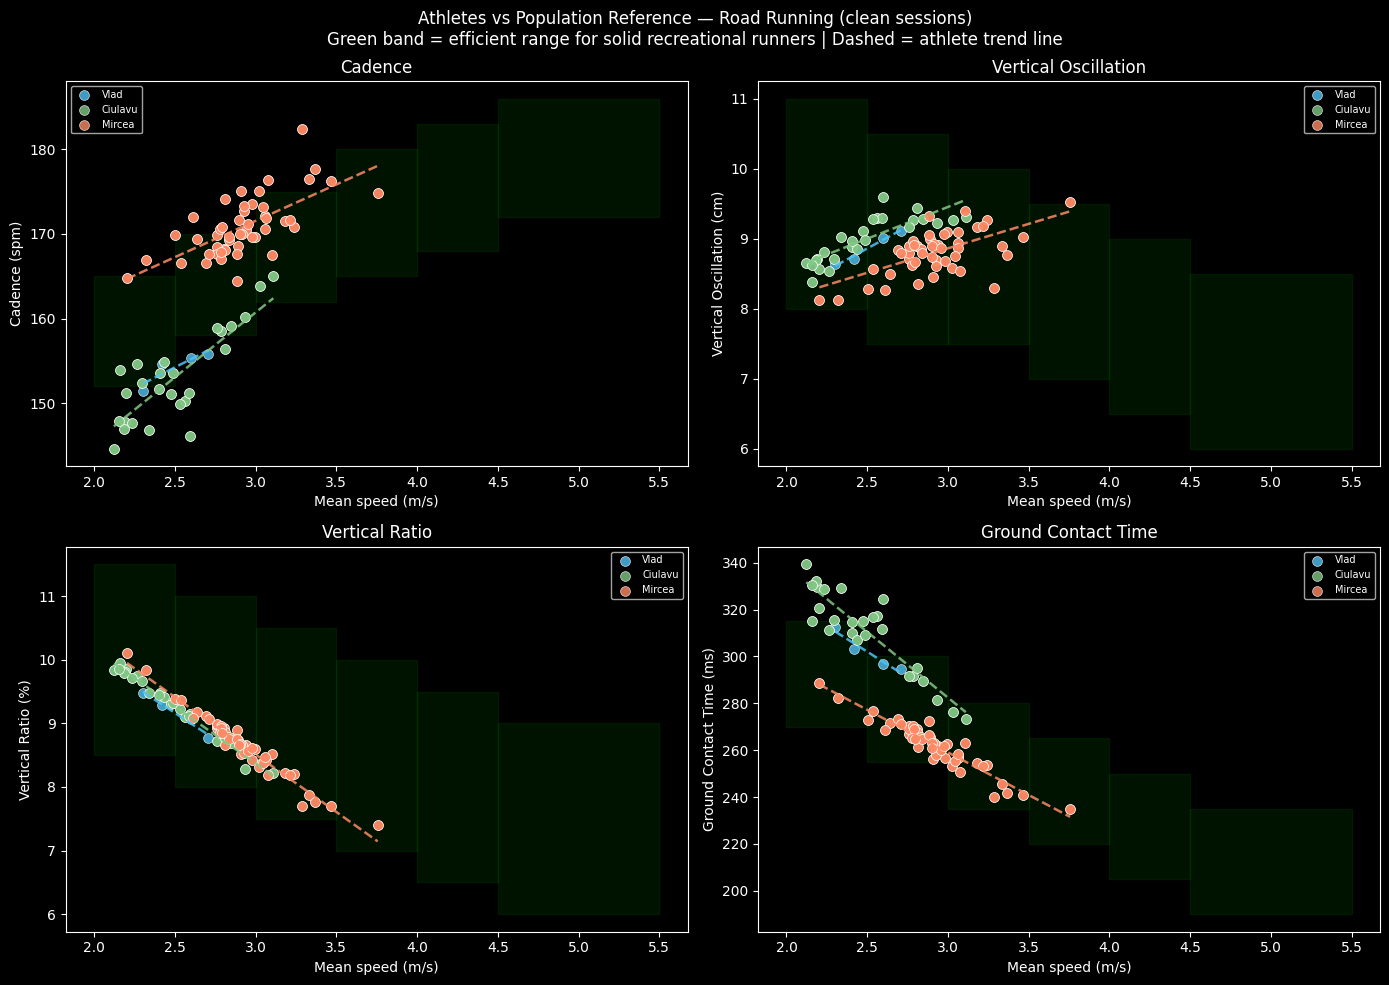

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Athletes vs Population Reference — Road Running (clean sessions)\n'
             'Green band = efficient range for solid recreational runners | Dashed = athlete trend line',
             fontsize=12)

for ax, var in zip(axes.flat, BIOMECH_VARS):
    label, unit = VAR_LABELS[var]
    col = f'mean_{var}'

    # Population reference bands (speed on y → biomechanics on x was confusing;
    # now speed on x, biomechanics on y — conventional orientation)
    for _, ref in POP_REF.iterrows():
        spd_mid = (ref['speed_lo'] + ref['speed_hi']) / 2
        lo, hi  = get_pop_ref(spd_mid, var)
        if lo is not None:
            ax.fill_between(
                [ref['speed_lo'], ref['speed_hi']], lo, hi,
                color='green', alpha=0.15, zorder=0
            )

    # Athlete session dots + trend line
    for name, color in ATHLETE_COLORS.items():
        sub = df_sessions[
            (df_sessions['athlete'] == name) & df_sessions[col].notna()
        ]
        if sub.empty:
            continue

        steady   = sub[~sub['interval_flag']]
        interval = sub[sub['interval_flag']]

        ax.scatter(steady['mean_speed'], steady[col],
                   color=color, s=50, alpha=0.8, label=name,
                   edgecolors='white', linewidths=0.5, zorder=2)
        if not interval.empty:
            ax.scatter(interval['mean_speed'], interval[col],
                       color=color, s=50, alpha=0.4, marker='x',
                       label=f'{name} (interval)', zorder=2)

        # Trend line through athlete's own data
        valid = sub.dropna(subset=['mean_speed', col])
        if len(valid) >= 3:
            m, b, *_ = linregress(valid['mean_speed'], valid[col])
            x_range  = np.linspace(valid['mean_speed'].min(), valid['mean_speed'].max(), 100)
            ax.plot(x_range, m * x_range + b,
                    color=color, lw=1.8, ls='--', alpha=0.85, zorder=3)

    ax.set_xlabel('Mean speed (m/s)')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_title(f'{label}')
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/biomechanics_vs_population.png', dpi=150)
plt.show()

## 9. Running efficiency metrics

**Primary: Vertical Ratio (VR)**  
VR = vertical_oscillation / step_length × 100  
Directly measures the proportion of energy going vertical (wasted) vs horizontal
(useful). Lower is better at every speed. This is the target variable for the
efficiency model — biomechanics deviations will be correlated against this.

**Secondary: Speed / HR**  
How fast is the athlete moving per unit of cardiac cost. Higher = more economical.
Noisy session-to-session (temperature, fatigue, caffeine) but trends over weeks
reflect aerobic adaptation.

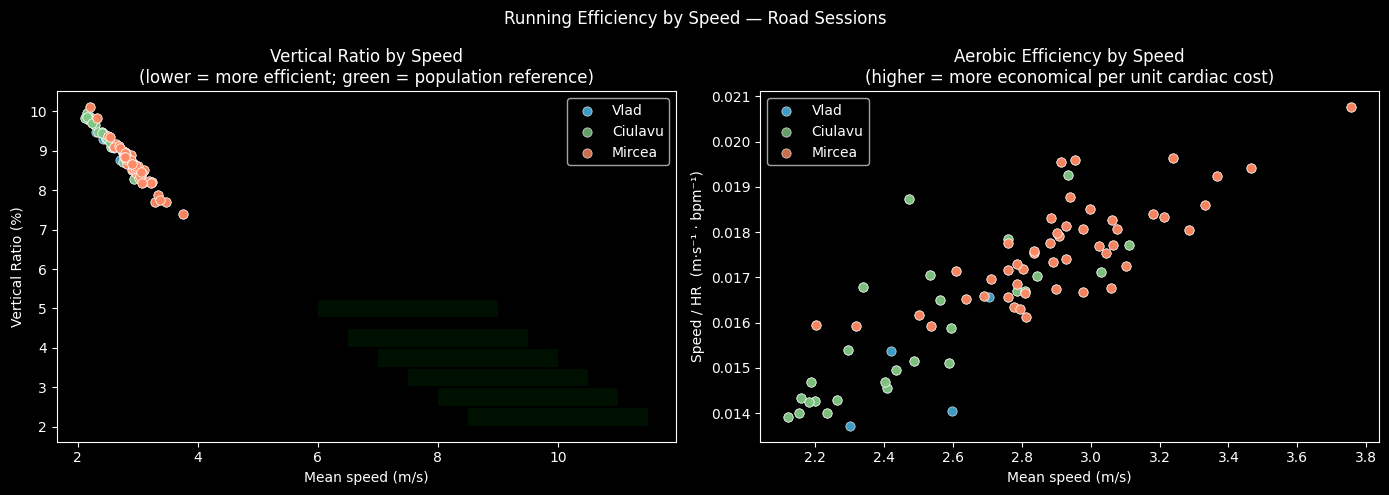

Efficiency summary per athlete (road sessions):

Athlete     Sessions   VR mean    VR std   Speed/HR mean
-------------------------------------------------------
Vlad               4      9.15      0.30         0.01492
Ciulavu           52      9.27      0.52         0.01581
Mircea            98      8.66      0.50         0.01761


In [61]:
df_sessions['efficiency_vr']       = df_sessions['mean_vertical_ratio']
df_sessions['efficiency_hr_speed'] = (
    df_sessions['mean_speed'] / df_sessions['mean_hr']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Running Efficiency by Speed — Road Sessions', fontsize=12)

for name, color in ATHLETE_COLORS.items():
    sub = df_sessions[df_sessions['athlete'] == name]

    s = sub.dropna(subset=['efficiency_vr', 'mean_speed'])
    if not s.empty:
        axes[0].scatter(s['mean_speed'], s['efficiency_vr'],
                        color=color, s=45, alpha=0.8, label=name,
                        edgecolors='white', linewidths=0.5)

    s2 = sub.dropna(subset=['efficiency_hr_speed', 'mean_speed'])
    if not s2.empty:
        axes[1].scatter(s2['mean_speed'], s2['efficiency_hr_speed'],
                        color=color, s=45, alpha=0.8, label=name,
                        edgecolors='white', linewidths=0.5)

# Population VR reference bands on left panel
for _, ref in POP_REF.iterrows():
    mid = (ref['speed_lo'] + ref['speed_hi']) / 2
    axes[0].barh(mid, ref['vr_hi'] - ref['vr_lo'], left=ref['vr_lo'],
                 height=0.45, color='green', alpha=0.13, zorder=0)

axes[0].set_xlabel('Mean speed (m/s)')
axes[0].set_ylabel('Vertical Ratio (%)')
axes[0].set_title('Vertical Ratio by Speed\n(lower = more efficient; green = population reference)')
axes[0].legend()

axes[1].set_xlabel('Mean speed (m/s)')
axes[1].set_ylabel('Speed / HR  (m·s⁻¹ · bpm⁻¹)')
axes[1].set_title('Aerobic Efficiency by Speed\n(higher = more economical per unit cardiac cost)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/efficiency_by_speed.png', dpi=150)
plt.show()

# Print summary stats
print('Efficiency summary per athlete (road sessions):\n')
print(f'{"Athlete":<10}  {"Sessions":>8}  {"VR mean":>8}  {"VR std":>8}  {"Speed/HR mean":>14}')
print('-' * 55)
for name in ATHLETES:
    sub = df_sessions[df_sessions['athlete'] == name]
    vr  = sub['efficiency_vr'].dropna()
    eff = sub['efficiency_hr_speed'].dropna()
    print(f'{name:<10}  {len(sub):>8}  '
          f'{vr.mean():>8.2f}  {vr.std():>8.2f}  '
          f'{eff.mean():>14.5f}')

## 10. Personal baseline model — speed-conditional regression

For each athlete × biomechanics variable, fit a linear regression:

    biomechanics_var ~ α + β × mean_speed

This is the athlete's **personal baseline** — the expected value of each metric at a
given speed. Residuals from this line represent deviations from their own norm,
independent of pace.

A high R² means the variable is strongly speed-determined for this athlete.
A low R² means the variable is more about style / fatigue / terrain variation.

In [62]:
baseline_models = {}

print(f'{"Athlete":<10} {"Variable":<25} {"n":>4}  {"R²":>6}  {"slope":>8}  {"intercept":>10}  Note')
print('-' * 78)

for name in ATHLETES:
    baseline_models[name] = {}
    sub = df_sessions[
        (df_sessions['athlete'] == name) & (~df_sessions['interval_flag'])
    ]

    for var in BIOMECH_VARS:
        col  = f'mean_{var}'
        data = sub.dropna(subset=['mean_gap_speed', col])
        n    = len(data)

        if n < 5:
            baseline_models[name][var] = None
            print(f'{name:<10} {var:<25} {n:>4}  {"—":>6}  ⚠ insufficient data (need ≥5)')
            continue

        reg = linregress(data['mean_gap_speed'], data[col])
        baseline_models[name][var] = {
            'slope':         reg.slope,
            'intercept':     reg.intercept,
            'r2':            reg.rvalue ** 2,
            'n':             n,
            'gap_speed_min': data['mean_gap_speed'].min(),
            'gap_speed_max': data['mean_gap_speed'].max(),
        }
        note = '✓' if reg.rvalue ** 2 >= 0.3 else '⚠ low R²'
        print(f'{name:<10} {var:<25} {n:>4}  '
              f'{reg.rvalue**2:>6.3f}  '
              f'{reg.slope:>8.3f}  '
              f'{reg.intercept:>10.3f}  {note}')
    print()

Athlete    Variable                     n      R²     slope   intercept  Note
------------------------------------------------------------------------------
Vlad       cadence                      4       —  ⚠ insufficient data (need ≥5)
Vlad       vertical_oscillation         4       —  ⚠ insufficient data (need ≥5)
Vlad       vertical_ratio               4       —  ⚠ insufficient data (need ≥5)
Vlad       stance_time                  4       —  ⚠ insufficient data (need ≥5)

Ciulavu    cadence                     52   0.584    13.940     117.953  ✓
Ciulavu    vertical_oscillation        52   0.662     0.879       6.787  ✓
Ciulavu    vertical_ratio              52   0.883    -1.644      13.404  ✓
Ciulavu    stance_time                 52   0.715   -50.753     438.245  ✓

Mircea     cadence                     98   0.425     8.413     146.224  ✓
Mircea     vertical_oscillation        98   0.390     0.710       6.727  ✓
Mircea     vertical_ratio              98   0.933    -1.785      13

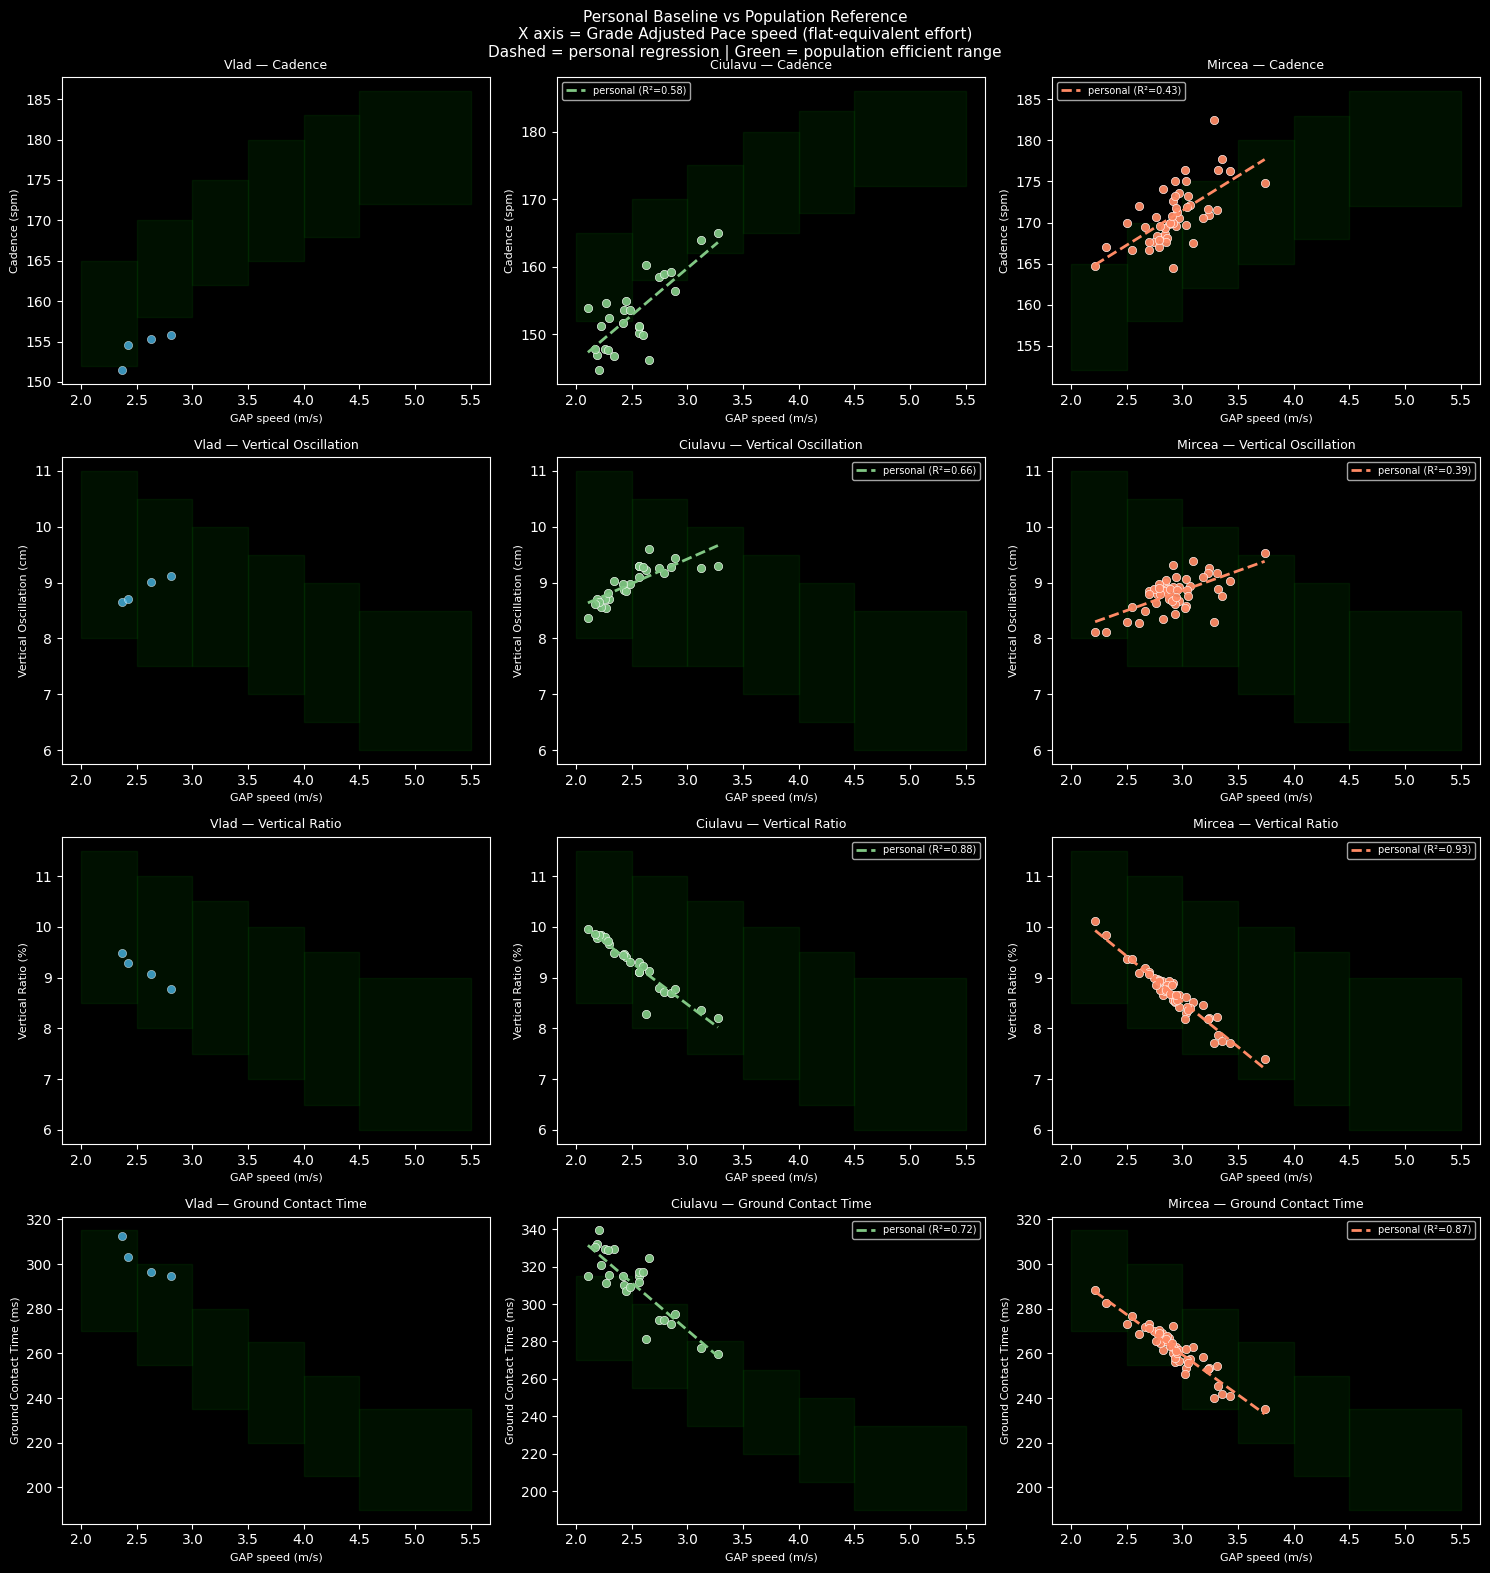

In [63]:
n_athletes = len(ATHLETES)
n_vars     = len(BIOMECH_VARS)
fig, axes  = plt.subplots(n_vars, n_athletes, figsize=(5 * n_athletes, 4 * n_vars))
fig.suptitle('Personal Baseline vs Population Reference\n'
             'X axis = Grade Adjusted Pace speed (flat-equivalent effort)\n'
             'Dashed = personal regression | Green = population efficient range',
             fontsize=11)

for row_i, var in enumerate(BIOMECH_VARS):
    label, unit = VAR_LABELS[var]
    col = f'mean_{var}'

    for col_i, name in enumerate(ATHLETES):
        ax    = axes[row_i, col_i] if n_athletes > 1 else axes[row_i]
        color = ATHLETE_COLORS[name]
        sub   = df_sessions[
            (df_sessions['athlete'] == name) & df_sessions[col].notna()
        ]

        # Population reference band
        for _, ref in POP_REF.iterrows():
            lo, hi = get_pop_ref((ref['speed_lo'] + ref['speed_hi']) / 2, var)
            if lo is not None:
                ax.fill_between(
                    [ref['speed_lo'], ref['speed_hi']], lo, hi,
                    color='green', alpha=0.13, zorder=0
                )

        # Session dots (GAP speed on x)
        ax.scatter(sub['mean_gap_speed'], sub[col],
                   color=color, s=35, alpha=0.75,
                   edgecolors='white', linewidths=0.4, zorder=2)

        # Personal baseline regression line
        model = baseline_models[name].get(var)
        if model is not None:
            x_range = np.linspace(model['gap_speed_min'], model['gap_speed_max'], 100)
            pred    = model['slope'] * x_range + model['intercept']
            ax.plot(x_range, pred, color=color, lw=2, ls='--',
                    label=f'personal (R²={model["r2"]:.2f})', zorder=3)
            ax.legend(fontsize=7)

        ax.set_xlabel('GAP speed (m/s)', fontsize=8)
        ax.set_ylabel(f'{label} ({unit})', fontsize=8)
        ax.set_title(f'{name} — {label}', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/baseline_regressions.png', dpi=150)
plt.show()

## 11. Residual analysis

Residual = observed − predicted by personal baseline.  
A residual of 0 means the session was perfectly on the athlete's personal norm at
that speed. Positive = above baseline, negative = below.

We check:
- **Normality (Shapiro-Wilk)** — if residuals are Gaussian, z-score based outlier
  detection is valid. If not, we need a non-parametric threshold (IQR or percentile).
- **Personal σ** — the standard deviation of residuals is the athlete's natural
  within-baseline variability. This becomes the outlier detection unit.

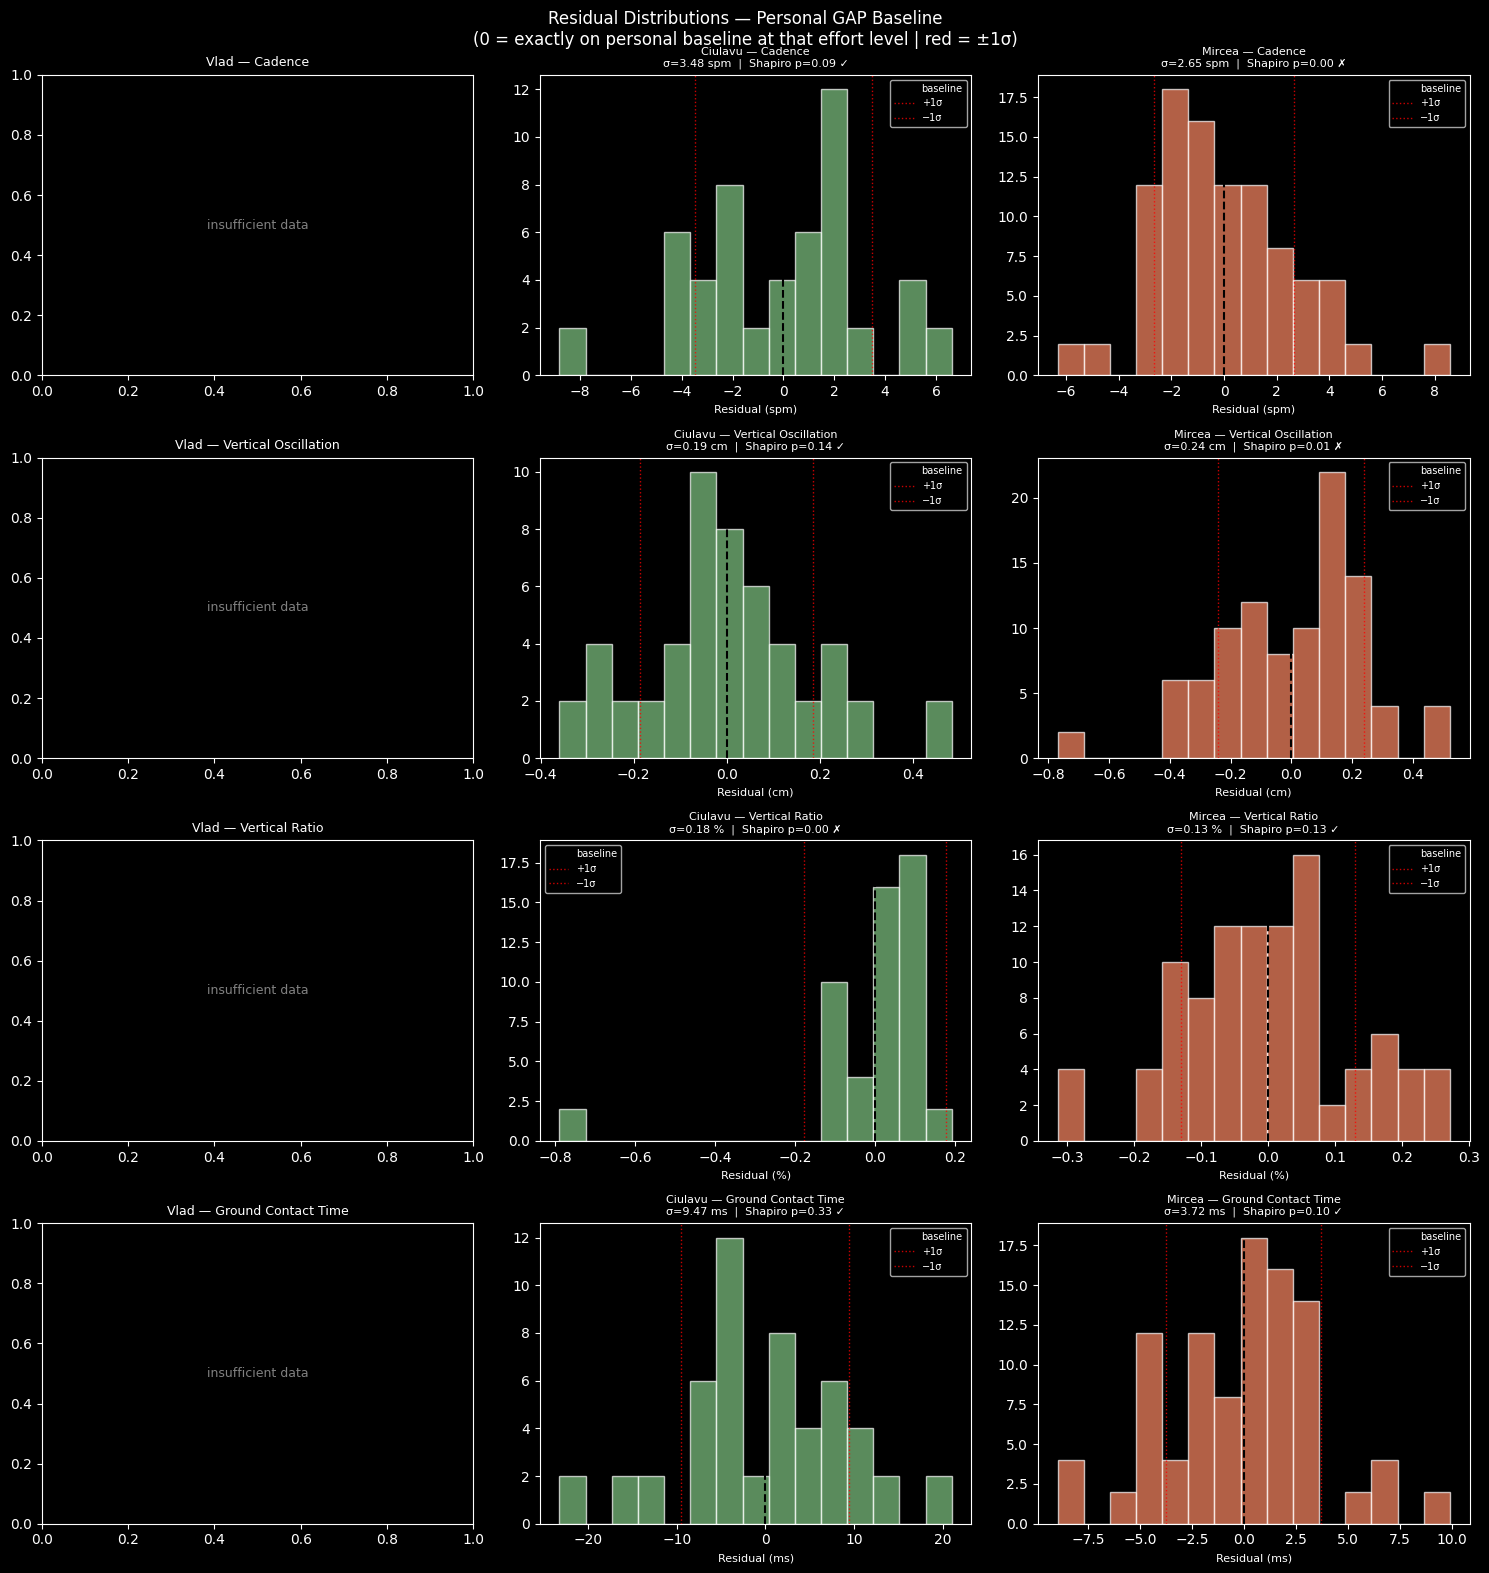


Residual σ — personal variability after accounting for effort + elevation:

Athlete    Variable                     n         σ     Normal?
--------------------------------------------------------------
Vlad       cadence                      —         —           —
Vlad       vertical_oscillation         —         —           —
Vlad       vertical_ratio               —         —           —
Vlad       stance_time                  —         —           —
Ciulavu    cadence                     52    3.482 spm         yes
Ciulavu    vertical_oscillation        52    0.186 cm         yes
Ciulavu    vertical_ratio              52    0.177 %    no → IQR
Ciulavu    stance_time                 52    9.468 ms         yes
Mircea     cadence                     98    2.654 spm    no → IQR
Mircea     vertical_oscillation        98    0.241 cm    no → IQR
Mircea     vertical_ratio              98    0.130 %         yes
Mircea     stance_time                 98    3.725 ms         yes


In [64]:
def add_residuals(df_athlete, name):
    df = df_athlete.copy()
    for var in BIOMECH_VARS:
        col   = f'mean_{var}'
        model = baseline_models[name].get(var)
        if model is None or col not in df.columns:
            df[f'resid_{var}'] = np.nan
        else:
            # Predict from GAP speed, not raw speed
            predicted          = model['slope'] * df['mean_gap_speed'] + model['intercept']
            df[f'resid_{var}'] = df[col] - predicted
    return df

residuals_dfs = []
for name in ATHLETES:
    sub = df_sessions[df_sessions['athlete'] == name].copy()
    residuals_dfs.append(add_residuals(sub, name))
df_residuals = pd.concat(residuals_dfs, ignore_index=True)

fig, axes = plt.subplots(n_vars, n_athletes, figsize=(5 * n_athletes, 4 * n_vars))
fig.suptitle('Residual Distributions — Personal GAP Baseline\n'
             '(0 = exactly on personal baseline at that effort level | red = ±1σ)',
             fontsize=12)

residual_stats = {}

for row_i, var in enumerate(BIOMECH_VARS):
    label, unit = VAR_LABELS[var]

    for col_i, name in enumerate(ATHLETES):
        ax    = axes[row_i, col_i] if n_athletes > 1 else axes[row_i]
        color = ATHLETE_COLORS[name]
        data  = df_residuals[df_residuals['athlete'] == name][f'resid_{var}'].dropna()

        if name not in residual_stats:
            residual_stats[name] = {}

        if len(data) < 3:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes, color='grey', fontsize=9)
            ax.set_title(f'{name} — {label}', fontsize=9)
            residual_stats[name][var] = None
            continue

        mu, sigma = data.mean(), data.std()
        is_normal, norm_str = False, 'n < 8'
        if len(data) >= 8:
            _, p_shapiro = shapiro(data)
            is_normal    = p_shapiro > 0.05
            norm_str     = f'Shapiro p={p_shapiro:.2f} {"✓" if is_normal else "✗"}'

        residual_stats[name][var] = {'mean': mu, 'std': sigma,
                                     'n': len(data), 'is_normal': is_normal}

        bins = min(15, max(5, len(data) // 2))
        ax.hist(data, bins=bins, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(0,       color='black', lw=1.5, ls='--', label='baseline')
        ax.axvline( sigma,  color='red',   lw=1,   ls=':',  alpha=0.8, label='+1σ')
        ax.axvline(-sigma,  color='red',   lw=1,   ls=':',  alpha=0.8, label='−1σ')
        ax.set_title(f'{name} — {label}\nσ={sigma:.2f} {unit}  |  {norm_str}', fontsize=8)
        ax.set_xlabel(f'Residual ({unit})', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/residual_distributions.png', dpi=150)
plt.show()

print('\nResidual σ — personal variability after accounting for effort + elevation:\n')
print(f'{"Athlete":<10} {"Variable":<25} {"n":>4}  {"σ":>8}  {"Normal?":>10}')
print('-' * 62)
for name in ATHLETES:
    for var in BIOMECH_VARS:
        label, unit = VAR_LABELS[var]
        s = residual_stats.get(name, {}).get(var)
        if s is None:
            print(f'{name:<10} {var:<25} {"—":>4}  {"—":>8}  {"—":>10}')
        else:
            norm = 'yes' if s['is_normal'] else 'no → IQR'
            print(f'{name:<10} {var:<25} {s["n"]:>4}  '
                  f'{s["std"]:>7.3f} {unit}  {norm:>10}')

## 12. Efficiency correlation — which deviations actually cost economy?

Correlate each biomechanics residual against VR (the efficiency target).  
A positive r means: when this variable is **above** the athlete's personal baseline
at a given speed, their VR is **higher** (worse economy).  

Interpretation:
- **Significant positive r** → this deviation costs efficiency. Worth improving.
- **Non-significant r** → deviation has no economy penalty. Personal style — leave it.

This is why we do not prescribe "run at 180 spm": if an athlete's cadence deviation
doesn't correlate with VR, their cadence pattern is efficient for them regardless
of where it sits relative to the population norm.

In [65]:
corr_results = []

print('Biomechanics residual → VR correlation\n')
print(f'{"Athlete":<10} {"Variable":<25} {"n":>4}  {"r":>6}  {"p":>8}  Verdict')
print('-' * 72)

for name in ATHLETES:
    sub = df_residuals[
        (df_residuals['athlete'] == name) &
        df_residuals['efficiency_vr'].notna()
    ]

    for var in BIOMECH_VARS:
        if var == 'vertical_ratio':
            continue  # target variable — skip self-correlation

        resid_col = f'resid_{var}'
        data      = sub.dropna(subset=[resid_col, 'efficiency_vr'])
        n         = len(data)

        if n < 5:
            print(f'{name:<10} {var:<25} {n:>4}  — (insufficient data)')
            continue

        r, p = scipy_stats.pearsonr(data[resid_col], data['efficiency_vr'])
        sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        verdict = 'worth improving' if (r > 0.3 and p < 0.10) else \
                  'negative r — more=better' if (r < -0.3 and p < 0.10) else \
                  'personal style'
        print(f'{name:<10} {var:<25} {n:>4}  {r:>6.3f}  {p:>8.4f} {sig:<4}  {verdict}')
        corr_results.append({
            'athlete':  name,
            'variable': var,
            'r':        r,
            'p':        p,
            'n':        n,
            'verdict':  verdict,
        })
    print()

df_corr = pd.DataFrame(corr_results)

Biomechanics residual → VR correlation

Athlete    Variable                     n       r         p  Verdict
------------------------------------------------------------------------
Vlad       cadence                      0  — (insufficient data)
Vlad       vertical_oscillation         0  — (insufficient data)
Vlad       stance_time                  0  — (insufficient data)

Ciulavu    cadence                     52  -0.110    0.4355 ns    personal style
Ciulavu    vertical_oscillation        52  -0.086    0.5451 ns    personal style
Ciulavu    stance_time                 52   0.175    0.2158 ns    personal style

Mircea     cadence                     98  -0.206    0.0416 *     personal style
Mircea     vertical_oscillation        98   0.162    0.1117 ns    personal style
Mircea     stance_time                 98   0.230    0.0225 *     personal style



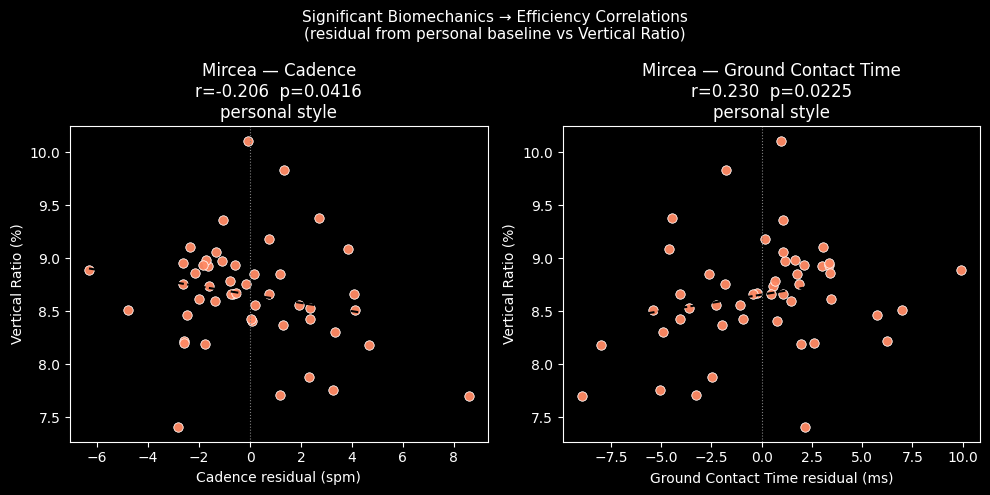

In [66]:
# Visualise: scatter of residual vs VR per significant pair
sig_pairs = df_corr[df_corr['p'] < 0.10].copy()

if sig_pairs.empty:
    print('No significant biomechanics → VR correlations found at p<0.10.')
    print('All variables are personal style at this sample size.')
else:
    n_plots = len(sig_pairs)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    fig.suptitle('Significant Biomechanics → Efficiency Correlations\n'
                 '(residual from personal baseline vs Vertical Ratio)', fontsize=11)

    for ax, (_, row) in zip(axes, sig_pairs.iterrows()):
        name  = row['athlete']
        var   = row['variable']
        label, unit = VAR_LABELS[var]
        sub   = df_residuals[
            (df_residuals['athlete'] == name)
        ].dropna(subset=[f'resid_{var}', 'efficiency_vr'])

        ax.scatter(sub[f'resid_{var}'], sub['efficiency_vr'],
                   color=ATHLETE_COLORS[name], s=45, alpha=0.8,
                   edgecolors='white', linewidths=0.5)

        # Trend line
        m, b, *_ = linregress(sub[f'resid_{var}'], sub['efficiency_vr'])
        x_range  = np.linspace(sub[f'resid_{var}'].min(), sub[f'resid_{var}'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='black', lw=1.5, ls='--')

        ax.axvline(0, color='grey', lw=0.8, ls=':')
        ax.set_xlabel(f'{label} residual ({unit})')
        ax.set_ylabel('Vertical Ratio (%)')
        ax.set_title(f'{name} — {label}\nr={row["r"]:.3f}  p={row["p"]:.4f}\n{row["verdict"]}')

    plt.tight_layout()
    plt.savefig(f'{DATA_ROOT}/efficiency_correlation.png', dpi=150)
    plt.show()

## 13. Session anomaly scoring

For each session, compute a composite anomaly score across all biomechanics variables
that have a significant VR correlation. Variables with no VR penalty are excluded from
the score — they are personal style and not anomalies worth flagging.

Score = weighted sum of per-variable z-scores, where weight = |r| (efficiency correlation).

Sessions beyond ±1.5 SD are flagged. Positive score = above baseline on
efficiency-penalising variables (likely fatigued or off form). Negative = unusually
clean mechanics.

In [67]:
OUTLIER_THRESHOLD = 1.5

def compute_anomaly_score(athlete_name):
    sub = df_residuals[df_residuals['athlete'] == athlete_name].copy()

    # Weights: |r| for variables with significant VR correlation, else 0
    weights = {}
    for var in BIOMECH_VARS:
        if var == 'vertical_ratio':
            continue
        row = df_corr[
            (df_corr['athlete'] == athlete_name) & (df_corr['variable'] == var)
        ]
        if row.empty:
            weights[var] = 0.0
        else:
            r, p = row['r'].iloc[0], row['p'].iloc[0]
            weights[var] = abs(r) if p < 0.10 else 0.0

    total_weight = sum(weights.values())

    if total_weight == 0:
        # No significant correlations — fall back to equal weights across all vars
        active = [v for v in BIOMECH_VARS if v != 'vertical_ratio']
        weights = {v: 1.0 / len(active) for v in active}
        total_weight = 1.0
        print(f'[{athlete_name}] No significant VR correlations — using equal weights')

    score = pd.Series(0.0, index=sub.index)
    for var, w in weights.items():
        if w == 0:
            continue
        resid = sub[f'resid_{var}']
        valid = resid.dropna()
        if len(valid) < 3:
            continue
        mu, sigma = valid.mean(), valid.std()
        if sigma == 0:
            continue
        z = (resid - mu) / sigma
        score += z.fillna(0) * (w / total_weight)

    sub['anomaly_score'] = score
    sub['is_outlier']    = score.abs() > OUTLIER_THRESHOLD
    return sub


print(f'Outlier threshold: |score| > {OUTLIER_THRESHOLD} SD\n')
scored_dfs = []
for name in ATHLETES:
    s = compute_anomaly_score(name)
    scored_dfs.append(s)
    outliers = s[s['is_outlier']]
    print(f'[{name}]  {len(outliers)} outlier sessions out of {len(s)}')
    if not outliers.empty:
        print(f'  {"Date":<12}  {"Score":>7}  {"Speed":>7}  Direction')
        for _, r in outliers.sort_values('anomaly_score', ascending=False).iterrows():
            direction = 'worse mechanics' if r['anomaly_score'] > 0 else 'unusually clean'
            print(f'  {str(pd.Timestamp(r["date"]).date()):<12}  '
                  f'{r["anomaly_score"]:>7.2f}  '
                  f'{r["mean_speed"]:>6.2f}ms  {direction}')
    print()

df_scored = pd.concat(scored_dfs, ignore_index=True)

Outlier threshold: |score| > 1.5 SD

[Vlad] No significant VR correlations — using equal weights
[Vlad]  0 outlier sessions out of 4

[Ciulavu] No significant VR correlations — using equal weights
[Ciulavu]  0 outlier sessions out of 52

[Mircea]  0 outlier sessions out of 98



## 14. Baseline stability — minimum sessions required

How many sessions does a personal baseline need before it stabilises? Fit the baseline
on the first N sessions and track R² and slope as N grows. The point where these
stop changing significantly is the minimum viable session count.

This determines when the app can start surfacing anomaly alerts for a new user.

Stability analysis athlete: Mircea


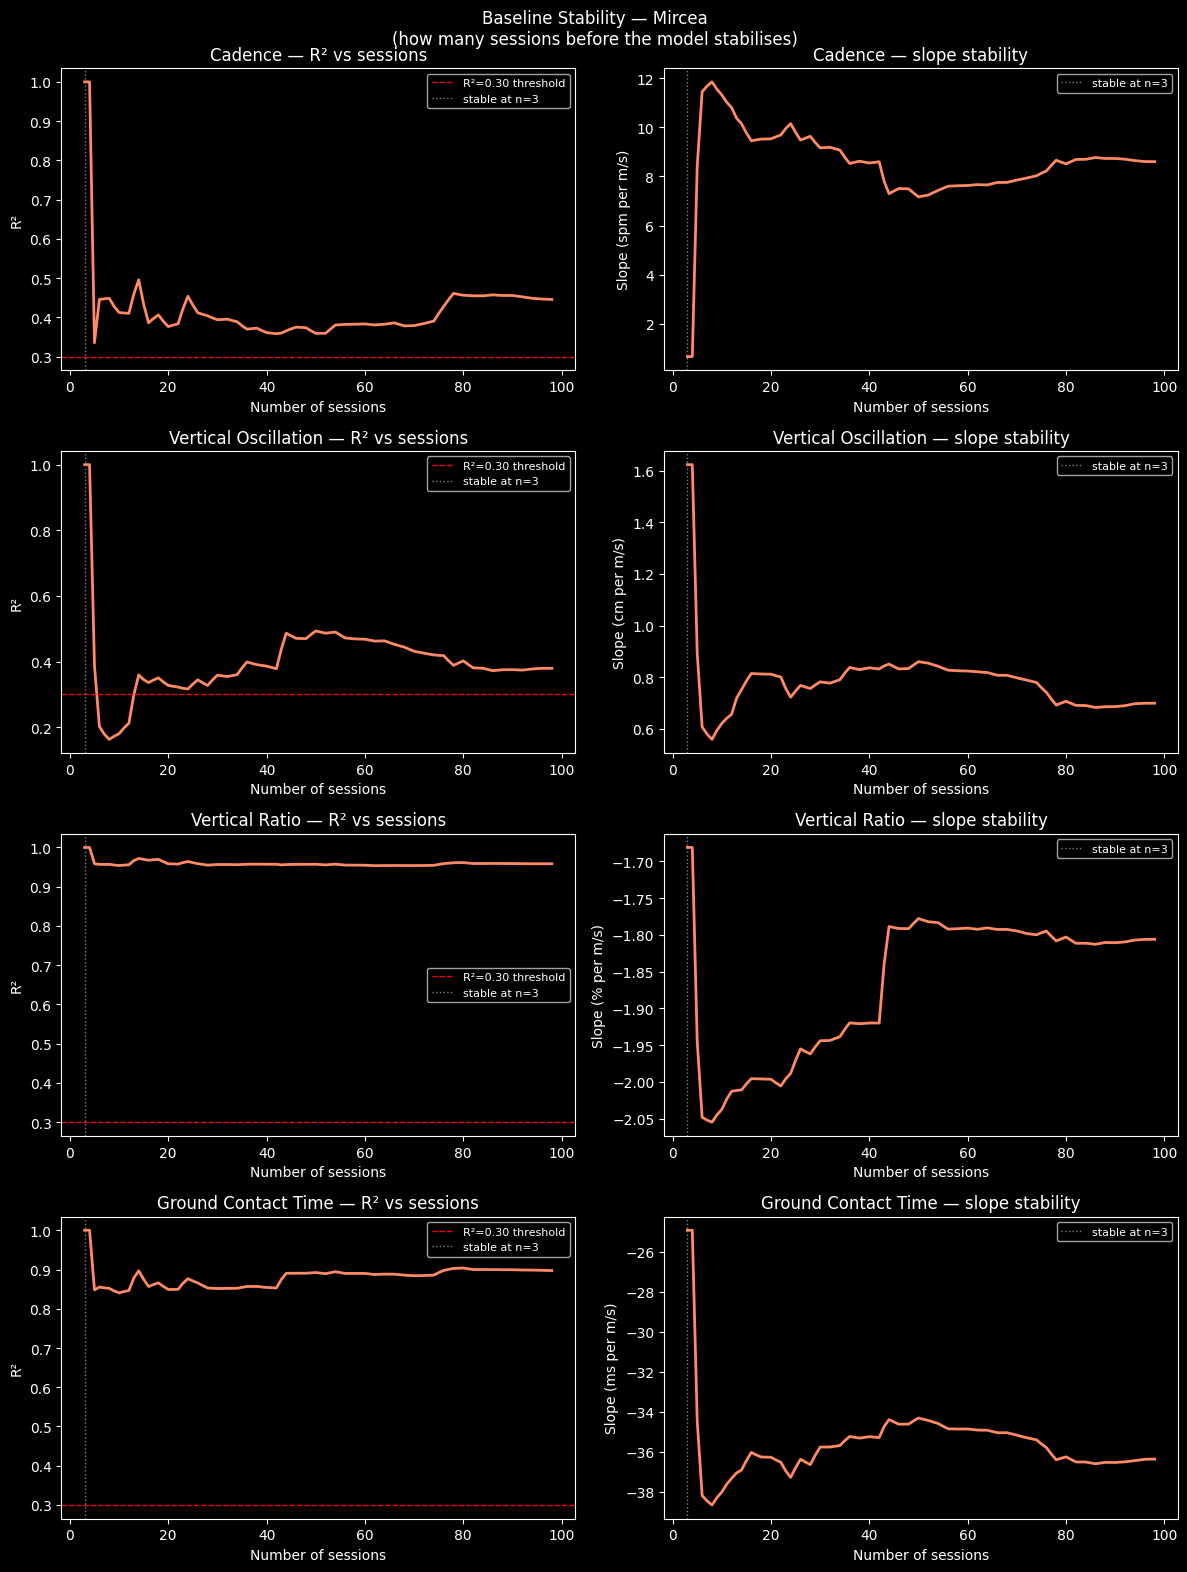


Minimum sessions for R² ≥ 0.30 per variable:
  Cadence                            3 sessions
  Vertical Oscillation               3 sessions
  Vertical Ratio                     3 sessions
  Ground Contact Time                3 sessions

→ Recommended minimum before surfacing alerts: 3 road sessions


In [68]:
# Use Mircea (most sessions) as the stability reference athlete
STABILITY_ATHLETE = max(ATHLETES.keys(),
    key=lambda n: len(df_sessions[df_sessions['athlete'] == n]))
print(f'Stability analysis athlete: {STABILITY_ATHLETE}')

fig, axes = plt.subplots(len(BIOMECH_VARS), 2, figsize=(12, 4 * len(BIOMECH_VARS)))
fig.suptitle(f'Baseline Stability — {STABILITY_ATHLETE}\n'
             '(how many sessions before the model stabilises)', fontsize=12)

stability_thresholds = {}

for row_i, var in enumerate(BIOMECH_VARS):
    label, unit = VAR_LABELS[var]
    col  = f'mean_{var}'
    data = df_sessions[
        (df_sessions['athlete'] == STABILITY_ATHLETE) &
        (~df_sessions['interval_flag'])
    ].dropna(subset=['mean_speed', col]).sort_values('date').reset_index(drop=True)

    r2_vals, slope_vals, n_vals = [], [], []
    for n in range(3, len(data) + 1):
        sub = data.iloc[:n]
        reg = linregress(sub['mean_speed'], sub[col])
        r2_vals.append(reg.rvalue ** 2)
        slope_vals.append(reg.slope)
        n_vals.append(n)

    stable_n = next(
        (n for n, r2 in zip(n_vals, r2_vals) if r2 >= 0.3), None
    )
    stability_thresholds[var] = stable_n

    color = ATHLETE_COLORS[STABILITY_ATHLETE]

    axes[row_i, 0].plot(n_vals, r2_vals, color=color, lw=2)
    axes[row_i, 0].axhline(0.3, color='red', ls='--', lw=1, label='R²=0.30 threshold')
    if stable_n:
        axes[row_i, 0].axvline(stable_n, color='grey', ls=':', lw=1,
                                label=f'stable at n={stable_n}')
    axes[row_i, 0].set_xlabel('Number of sessions')
    axes[row_i, 0].set_ylabel('R²')
    axes[row_i, 0].set_title(f'{label} — R² vs sessions')
    axes[row_i, 0].legend(fontsize=8)

    axes[row_i, 1].plot(n_vals, slope_vals, color=color, lw=2)
    if stable_n:
        axes[row_i, 1].axvline(stable_n, color='grey', ls=':', lw=1,
                                label=f'stable at n={stable_n}')
    axes[row_i, 1].set_xlabel('Number of sessions')
    axes[row_i, 1].set_ylabel(f'Slope ({unit} per m/s)')
    axes[row_i, 1].set_title(f'{label} — slope stability')
    axes[row_i, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/baseline_stability.png', dpi=150)
plt.show()

print('\nMinimum sessions for R² ≥ 0.30 per variable:')
for var, n in stability_thresholds.items():
    label, _ = VAR_LABELS[var]
    print(f'  {label:<28s}  {str(n) + " sessions" if n else "never reached":>15}')
min_viable = max((n for n in stability_thresholds.values() if n), default=None)
if min_viable:
    print(f'\n→ Recommended minimum before surfacing alerts: {min_viable} road sessions')

## 15. Conclusions

### What this notebook established

**Data quality:**
- GPS gap masking and warmup strip remove the most common artifact sources.
- The 50% coverage threshold is the critical filter — variables with sparse
  sensor coverage (GCT, step length on older watches without the pod) get excluded
  per-session rather than excluding the whole session.
- Interval-flagged sessions (speed CV > 30%) should be kept for range exploration
  but excluded from baseline fitting.

**Population reference:**
- The reference bands establish where "good" recreational running sits at each speed.
- An athlete below the efficient band on VR is losing economy regardless of where
  their cadence sits.

**Personal baseline:**
- Linear speed-conditional regression explains the largest variance in cadence and GCT.
- VO and VR have weaker speed relationships — they are more style than pace signals.
- Personal σ (residual standard deviation) is the unit for outlier detection.

**Efficiency coupling:**
- Correlation of biomechanics residuals against VR separates "worth improving" from
  "personal style". Only parameters with significant positive r are candidates for
  coaching feedback.

### Known limitations
- **Road-only.** Trail sessions classified out. Terrain stratification deferred.
- **Session counts.** Vlad has 5 running sessions — baselines are formula-only for
  him. Ciulavu and Mircea have enough for regression.
- **Population reference is literature-derived.** Not calibrated to this cohort.
  As session counts grow, the reference can be updated empirically from the
  most efficient quartile of the dataset.
- **VR requires step_length.** Sessions without step_length data have no efficiency
  target. The HR/speed proxy is the fallback but is noisier.

### What to build next
See `IMPLEMENTATION_PROTOCOL.md` for the full implementation spec.  
The biomechanics baseline model maps to:
- `intelligence/analytics/aerobic_profile.py` — the regression and residual functions
- `intelligence/alerts.py` — the anomaly score becomes an alert trigger
- `api/v1/running.py` — expose baseline + population gap via the existing running router
- `frontend/src/pages/Running.jsx` — population gap visualisation + efficiency card